In [1]:
import h5py
import numpy as np
from scipy import signal
from scipy.signal import welch, csd
import matplotlib.pyplot as plt
from os import listdir
from scipy import fft
import pickle
from datetime import datetime
import sys
import os
# Specify the absolute path to the 'libraries' directory
library_path = '/home/leo_maria/Desktop/UWA/MAGE/libraries/'  # Adjust this to the actual absolute path

# Add the 'libraries' directory to sys.path
sys.path.append(library_path)

# Now you can import utils.py as a module
import Analysis_functions

Open pickle file with events

In [2]:
folder = r'/home/leo_maria/Desktop/UWA/MAGE/MAGE4/Analysis/run1-Teff/'

with open(folder + 'event_catalogue-strain-Teff.pkl', 'rb') as f:
    event_catalogue = pickle.load(f)
    
with open(folder + 'co_event_strain-Teff.pkl', 'rb') as f:
    co_events = pickle.load(f)

Ninputs, Nchannels, Nsamples, Fs, dt, fdemods, t_start = Analysis_functions.get_meta_data_from_first_file('/home/leo_maria/Desktop/UWA/MAGE/MAGE4/run1/run1-8.hdf5') 

## Look for (very) large events and store them in another dictionary


In [12]:
import numpy as np

def large_events_by_SNR(event_catalogue, min_snr, max_snr):
    """
    Selects and saves large events with SNR greater than min_snr and smaller than max_snr,
    along with other event details (time, SNR, input AI, channel, frequency, amplitude, file N, index).
    
    Args:
        event_catalogue (dict): Dictionary containing event data, where each event has keys like 'SNR', 'input AI', 'channel', etc.
        min_snr (float): Minimum SNR value.
        max_snr (float): Maximum SNR value.
        
    Returns:
        dict: Dictionary with event channels and input AI values as keys, containing lists of large event details.
    """
    large_events = {}

    # Loop over all unique values for 'input AI' and 'channel' and find large events based on SNR
    for ai_value in [0, 1]:  # For AI = 0 and AI = 1
        for channel in range(1, 17):  # Assuming channels 1 to 16
            # Get the list of events for a specific channel and input AI
            key = f"AI{ai_value}_ch{channel}_events"
            large_event_details = []  # List to hold all details for large events

            # Loop over the event_catalogue and apply condition based on 'SNR'
            for index, event in enumerate(event_catalogue):
                if (event_catalogue[event]['input AI'] == ai_value and
                    event_catalogue[event]['channel'] == channel):
                    
                    snr_value = event_catalogue[event]['SNR']
                    if min_snr < snr_value < max_snr:  # Check if SNR is within the specified range
                        # Collect all relevant event information
                        event_info = {
                            'time': event_catalogue[event]['time'],
                            'SNR': snr_value,
                            'input AI': event_catalogue[event]['input AI'],
                            'channel': event_catalogue[event]['channel'],
                            'frequency': event_catalogue[event]['frequency'],
                            'amplitude': event_catalogue[event]['amplitude'],
                            'file N': event_catalogue[event]['file N'],
                            'index': event_catalogue[event]['index']
                        }
                        large_event_details.append(event_info)

            # Save the large event details
            large_events[key] = large_event_details

    return large_events

# Example usage
min_snr = 4
max_snr = 50

# Assuming event_catalogue is your data dictionary
large_event_data = large_events_by_SNR(event_catalogue, min_snr, max_snr)

# Accessing the large events
for key, event_list in large_event_data.items():
    print(f"Large events for {key}:")
    for event_info in event_list:
        print(event_info)
    print()


Large events for AI0_ch1_events:

Large events for AI0_ch2_events:

Large events for AI0_ch3_events:
{'time': datetime.datetime(2024, 11, 13, 18, 24, 41, 771043), 'SNR': 4.0658237526753265, 'input AI': 0, 'channel': 3, 'frequency': 5088522.0, 'amplitude': (1.1371427826755853e-16+7.325781482721016e-17j), 'file N': 170.0, 'index': 220516}
{'time': datetime.datetime(2024, 11, 11, 4, 26, 12, 375792), 'SNR': 4.294776062161012, 'input AI': 0, 'channel': 3, 'frequency': 5088522.0, 'amplitude': (1.3969469680331732e-16+6.852438467329797e-17j), 'file N': 8.0, 'index': 111251}

Large events for AI0_ch4_events:

Large events for AI0_ch5_events:
{'time': datetime.datetime(2024, 11, 12, 7, 18, 16, 591190), 'SNR': 4.189990706261124, 'input AI': 0, 'channel': 5, 'frequency': 5577301.0, 'amplitude': (1.1059551433190934e-16-4.26696573012396e-17j), 'file N': 78.0, 'index': 234501}

Large events for AI0_ch6_events:

Large events for AI0_ch7_events:

Large events for AI0_ch8_events:

Large events for AI0_c

## Access the dictionary and zoom in the very large events


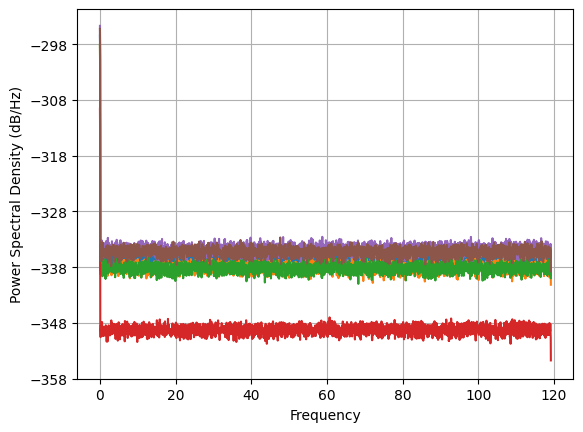

In [13]:

kappa=np.zeros((Ninputs, Nchannels))
NFFT=2**13
from scipy.constants import k
def read_two_column_data(file_path):
    data = np.loadtxt(file_path)
    column_1 = data[:, 0]  # First column
    column_2 = data[:, 1]  # Second column
    return np.array([column_1, column_2])

Vphi = read_two_column_data('/home/leo_maria//Desktop/UWA/MAGE/MAGE4/calibration/Vphi_squids_quartz_order.txt')
Rbaw = read_two_column_data('/home/leo_maria//Desktop/UWA/MAGE/MAGE4/calibration/Rs_new.txt')
Lin = 400e-9
Min = np.array([1 / 0.49 / 1e-6, 1 / 0.517 / 1e-6])
meff = Analysis_functions.get_eff_mass('/home/leo_maria/Desktop/UWA/MAGE/MAGE4/calibration/Meff.txt')
Qs = np.zeros((Ninputs, Nchannels))
f_res = np.zeros_like(Qs)


def open_files_from_large_events(large_event_data, hdf5_folder_path):
    """
    Opens the HDF5 files referenced in the 'file N' key of the large_event_data and processes them.
    
    Args:
        large_event_data (dict): Dictionary containing the large event data with 'file N' as part of the info.
        hdf5_folder_path (str): The path where the HDF5 files are stored (without the file extension).
        
    Returns:
        dict: A dictionary with the contents of the opened HDF5 files for each event.
    """
    file_contents = {}
    run_num = 1
    # Iterate over the large event data dictionary
    for key, event_list in large_event_data.items():
        for event_info in event_list:
            # Extract the file number from the 'file N' key
            file_number = event_info['file N']
            
            # Construct the file name based on the file number
            file_name = os.path.join(hdf5_folder_path, f"run{run_num}-{int(file_number)}.hdf5")
            # Open the HDF5 file
            try:
            
                # Read the contents of the HDF5 file (you can adapt this part to your needs)
                ai = event_info['input AI']
                ch = event_info['channel']-1
                index = event_info['index']
                span = 2000
                iq = Analysis_functions.retrieve_IQ_td(file_name)
                i_data = iq[ai, ch, 0, :]
                q_data = iq[ai, ch, 1, :]
                r_data = np.sqrt(i_data **2 + q_data**2)
                freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
                f_res[ai, ch], Qs[ai,ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis_onlyFandQ(Sx[ai,ch,:], freqs[ai,ch,:], fdemods[ai,ch], ai, ch, Plot=False, start=500, stop=1300)
                kappa = np.sqrt(fdemods[ai,ch]*2*np.pi*meff[ch]/(Qs[ai,ch]*Rbaw[ai,ch]))
                strain = Analysis_functions.R_to_strain(r_data[:], Fs, fdemods[ai,ch], Vphi[ai,ch], Min[ai], kappa)
                tau = Qs[ai,ch] /np.pi / f_res[ai,ch]
                Nfilter=int(Fs*5*tau)
                t_sig = 1/Fs*np.linspace(0, Nfilter, Nfilter)
                template = np.exp(-t_sig/(2 * tau)) # template construction
                SNR, filtered_strain = Analysis_functions.optimal_filter(strain, template, Fs, NFFT)
                # Store the file content in the dictionary
                if file_number not in file_contents:
                    file_contents[file_number] = []
                file_contents[file_number].append({
                    'event_index': event_info['index'],
                    'filtered_strain': filtered_strain,
                    'unfiltered_strain': strain,
                    'SNR_time_series': SNR,
                    'max SNR': np.max(SNR),
                    'max SNR index': np.where(SNR == np.max(SNR))[0],
                    'AI' : ai,
                    'channel': ch + 1,
                })

            except Exception as e:
                print(f"Error opening file {file_name}: {e}")

    return file_contents

# Example usage
hdf5_folder_path = '/home/leo_maria/Desktop/UWA/MAGE/MAGE4/run1'
# Assuming large_event_data is already generated from the previous steps
file_data = open_files_from_large_events(large_event_data, hdf5_folder_path)




Contents of file 170.0.hdf5:


/home/leo_maria/.local/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


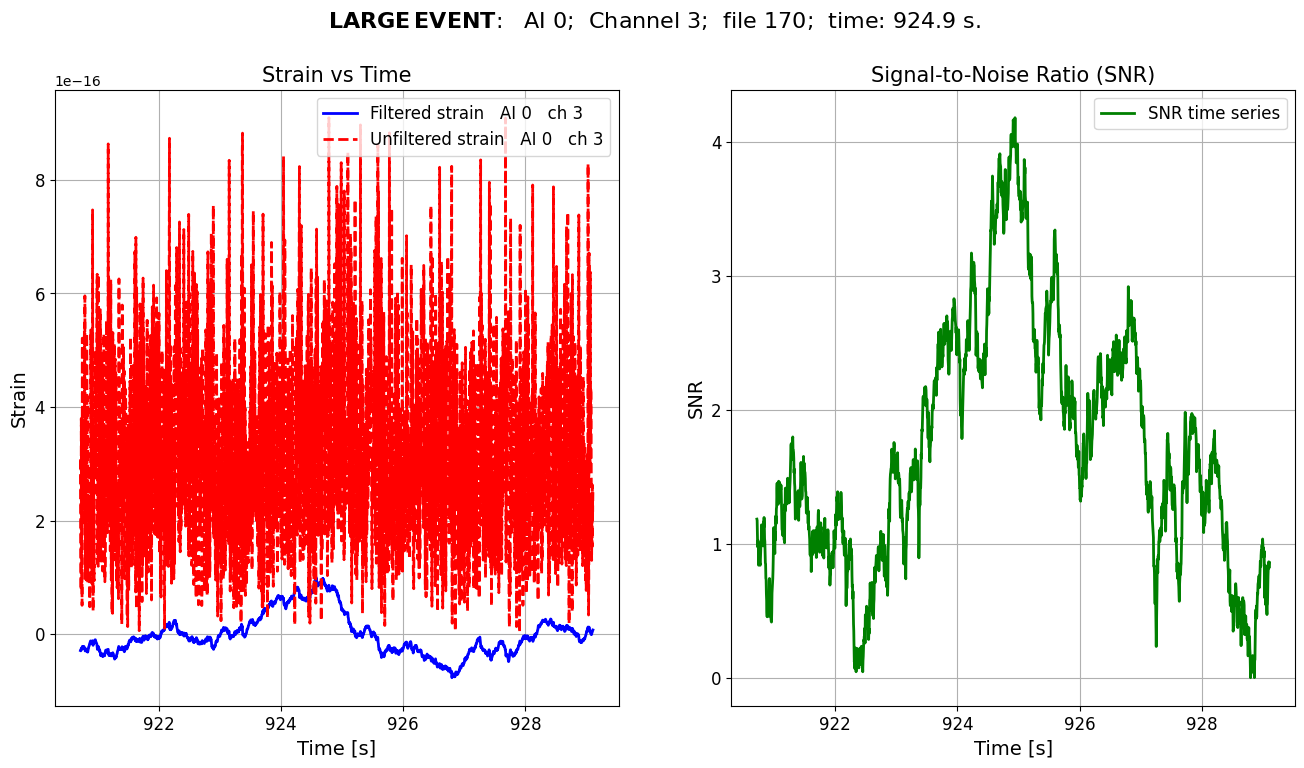

Event index: 220516
Max snr 4.177533611176236
Max snr index [220523]

Contents of file 8.0.hdf5:


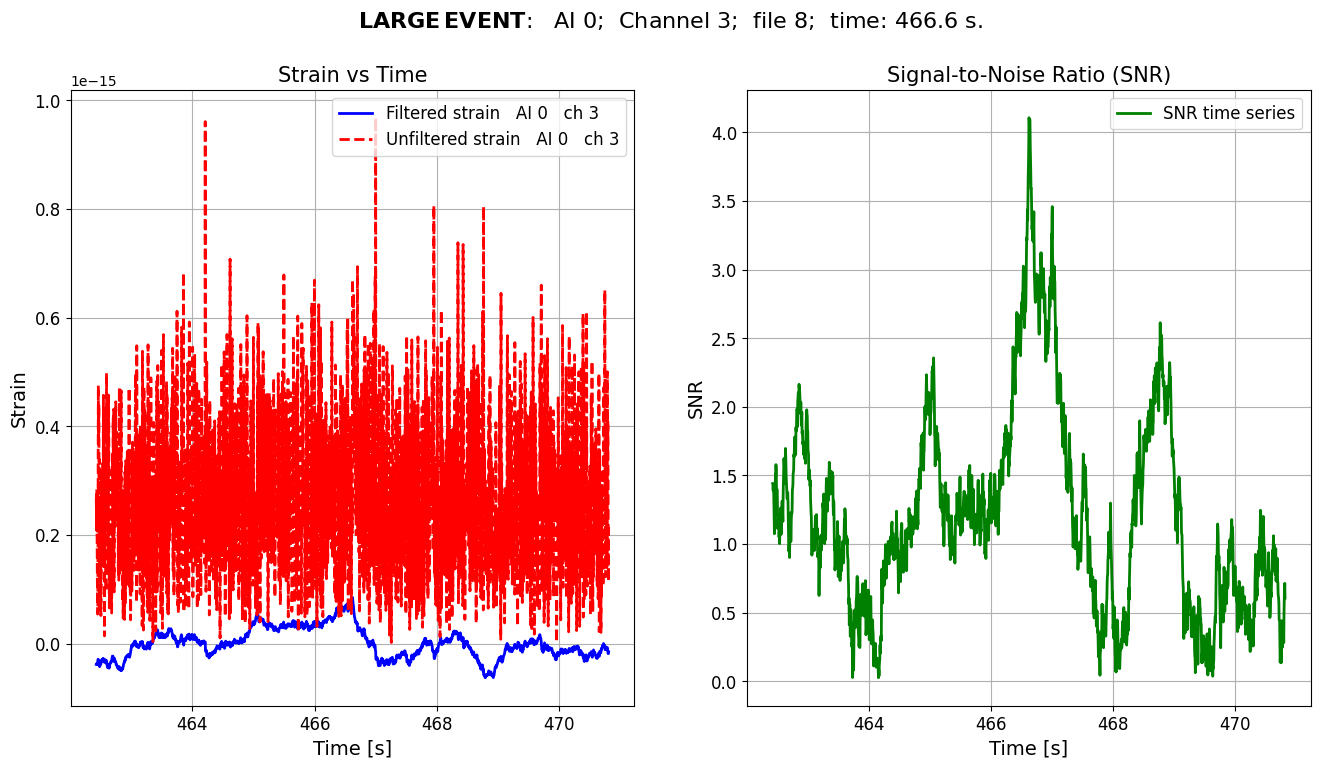

Event index: 111251
Max snr 4.10719340464468
Max snr index [111251]


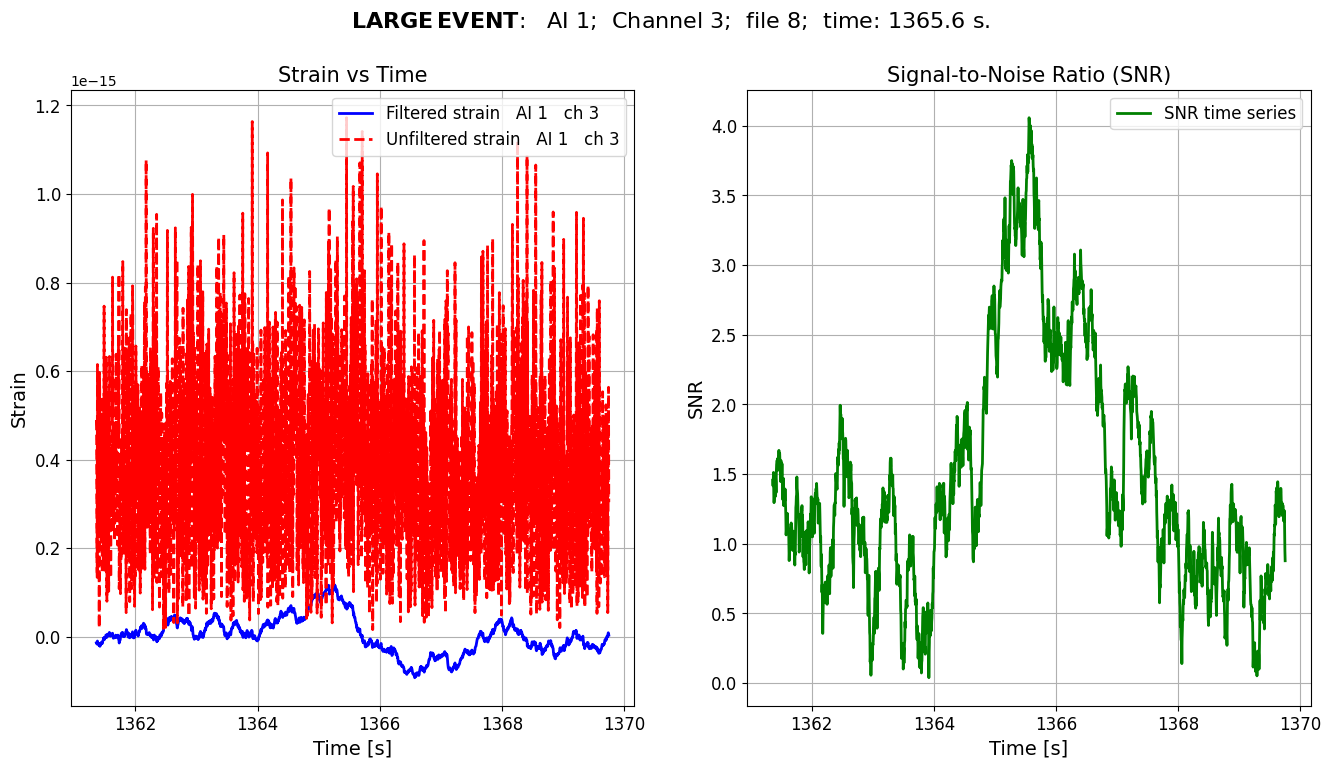

Event index: 325574
Max snr 4.057198033344578
Max snr index [325574]


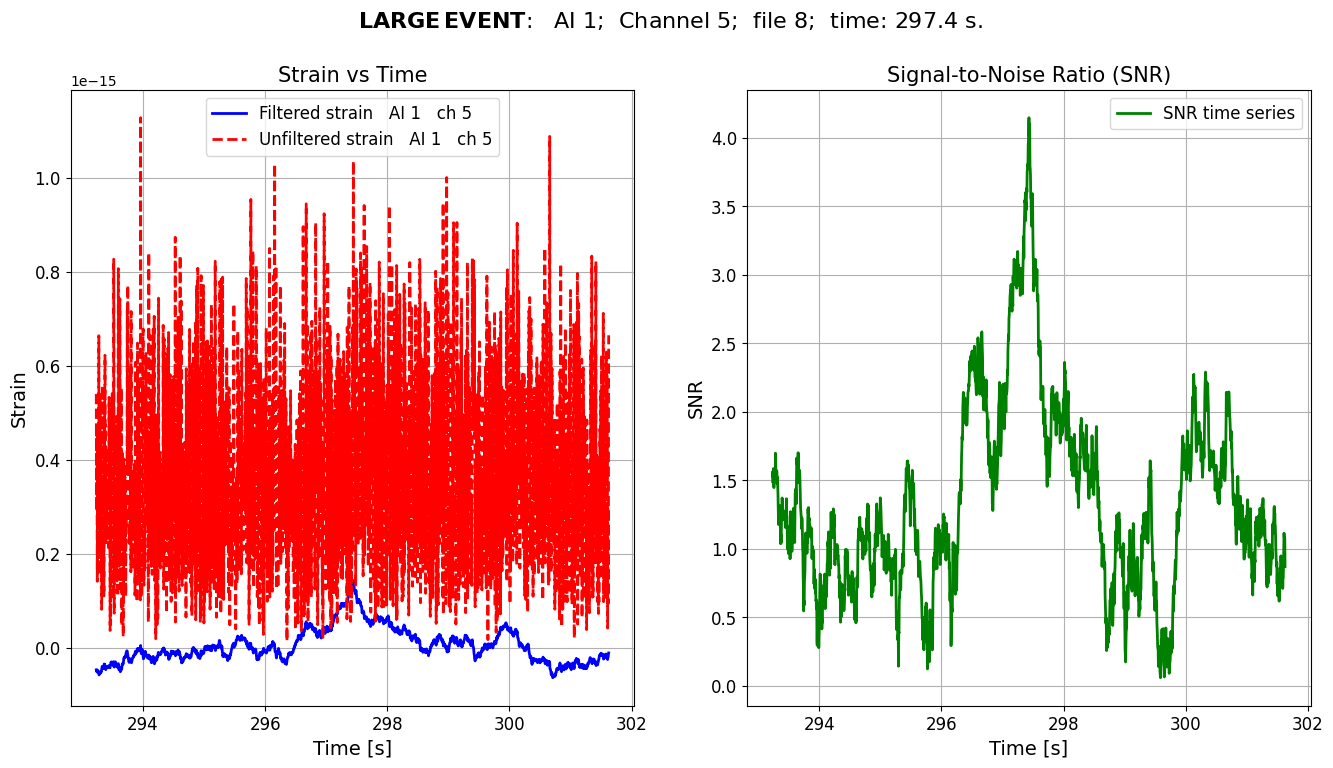

Event index: 70913
Max snr 4.145900951515966
Max snr index [70913]

Contents of file 78.0.hdf5:


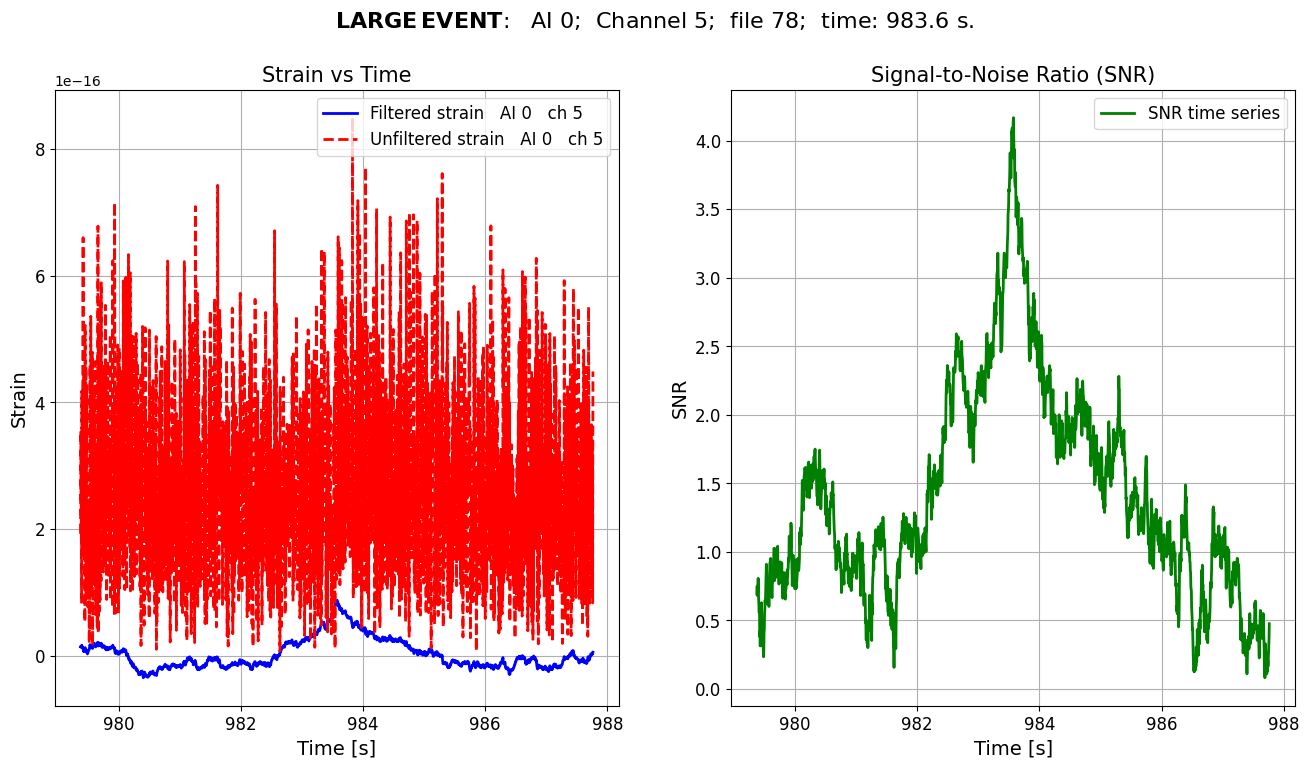

Event index: 234501
Max snr 4.167696779844765
Max snr index [234502]

Contents of file 308.0.hdf5:


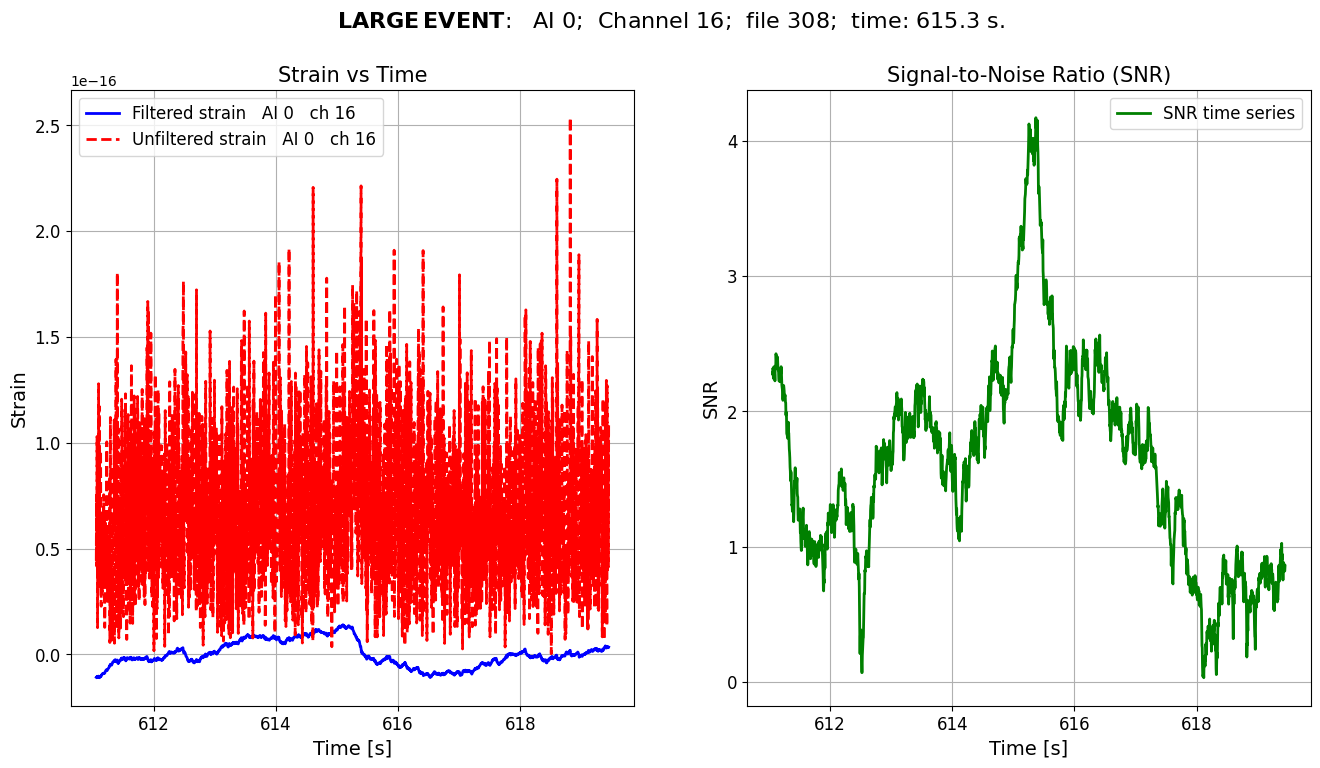

Event index: 146688
Max snr 4.171889832244248
Max snr index [146715]



In [30]:
# Print the contents of the files

half_span = int(1000)

for file_number, events in file_data.items():
    print(f"Contents of file {file_number}.hdf5:")
    for event in events:
        index = int(event['event_index'])
        #index = int(event['max SNR index'])
        if half_span >= index:
            half_span = index - 1
        ai =event['AI']
        ch = event['channel']
        
        filt_st = event['filtered_strain']
       
        unfilt_st = event['unfiltered_strain']
        SNR = event['SNR_time_series']
        time = dt *  np.linspace(index- half_span, index + half_span, 2*half_span)

        # Create a 1x2 grid for subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Plot for filtered and unfiltered strain on the first subplot
        ax1.plot(time, filt_st[index-half_span : index + half_span], label='Filtered strain   AI ' + str(ai) + '   ch ' + str(ch), color='blue', linewidth=2)
        ax1.plot(time, unfilt_st[index-half_span : index + half_span], label='Unfiltered strain   AI ' + str(ai) + '   ch ' + str(ch), color='red', linestyle='--', linewidth=2)
        ax1.set_xlabel('Time [s]', fontsize=14)
        ax1.set_ylabel('Strain', fontsize=14)
        ax1.set_title('Strain vs Time', fontsize=15)
        ax1.legend(fontsize=12)
        ax1.grid(True)
        ax1.tick_params(axis='both', labelsize=12)

        # Plot for SNR on the second subplot
        ax2.plot(time, SNR[index - half_span: index + half_span], label='SNR time series', color='green', linewidth=2)
        ax2.set_xlabel('Time [s]', fontsize=14)
        ax2.set_ylabel('SNR', fontsize=14)
        ax2.set_title('Signal-to-Noise Ratio (SNR)', fontsize=15)
        ax2.legend(fontsize=12)
        ax2.grid(True)
        ax2.tick_params(axis='both', labelsize=12)

        # Adjust layout to prevent overlap
        plt.suptitle(r'${\bf LARGE \, EVENT}$:   AI ' + str(ai) + ';  Channel ' + str (ch) + ';  file ' + str(int(file_number)) +  ';  time: ' + str(np.round(time[time.size//2],1)) + ' s.' , fontsize=16)        # Show the plots
        plt.show()

        # Print the event details
        print(f"Event index: {index}")  # Printing a snippet of the data
        print('Max snr', event['max SNR'])
        print('Max snr index', event['max SNR index'])

        half_span = int(1000)
    print()